# Test en Machine Learning
## Prétraitement de données

### 1- faites les importations des bibliothèques nécessaires

In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

### 2- importer les données du fichier "advc.csv"

In [2]:
df = pd.read_csv("data_survived.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.DataFrame'>


### 3- afficher un échontillon du dataframe

In [3]:
df.head()

,Diagnosed_Condition,Patient_ID,Patient_Age,BMI,Smoker,Residence,mental_condition,Number_of_prev_cond,Survived_1_year
0,47,8433,60,21.655523,NO,URBAN,Stable,2.0,1.0
1,3,2972,2,28.852743,NO,RURAL,Stable,3.0,0.0
2,7,8608,20,26.179725,NO,RURAL,Stable,2.0,1.0
3,31,10074,8,22.638945,NO,RURAL,Stable,2.0,0.0
4,43,7462,53,21.326131,NO,RURAL,Stable,1.0,1.0


### 4- afficher toutes les variables du dataset et leurs types respectifs

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23732 entries, 0 to 23731
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Diagnosed_Condition  23732 non-null  int64  
 1   Patient_ID           23732 non-null  int64  
 2   Patient_Age          23732 non-null  int64  
 3   BMI                  23732 non-null  float64
 4   Smoker               23731 non-null  str    
 5   Residence            23731 non-null  str    
 6   mental_condition     23731 non-null  str    
 7   Number_of_prev_cond  22435 non-null  float64
 8   Survived_1_year      23731 non-null  float64
dtypes: float64(3), int64(3), str(3)
memory usage: 1.6 MB


### 5-Afficher le nombre de lignes et de colonnes du dataframe

In [5]:
df.shape

(23732, 9)

In [6]:
df.describe()

,Diagnosed_Condition,Patient_ID,Patient_Age,BMI,Number_of_prev_cond,Survived_1_year
count,23732.000000,23732.000000,23732.000000,23732.000000,22435.000000,23731.000000
mean,26.378856,6240.330187,33.200910,23.437357,1.750568,0.633307
std,15.096335,3604.144830,19.522702,3.782707,0.770725,0.481912
min,0.000000,1.000000,0.000000,1.089300,1.000000,0.000000
25%,13.000000,3128.000000,16.000000,20.197874,1.000000,0.000000
50%,26.000000,6228.500000,33.000000,23.369943,2.000000,1.000000
75%,39.000000,9364.250000,50.000000,26.729231,2.000000,1.000000
max,52.000000,12514.000000,142.000000,29.999579,5.000000,1.000000


### 6- Quelles sont les colonnes qui  contiennent des valeurs nulls ? Endéduire le nombre de valeurs nulls

In [7]:
df.isnull().sum()

Diagnosed_Condition       0
Patient_ID                0
Patient_Age               0
BMI                       0
Smoker                    1
Residence                 1
mental_condition          1
Number_of_prev_cond    1297
Survived_1_year           1
dtype: int64

### 7-remplacer les valeurs manquantes dans la colonne "Number_of_prev_cond" par la moyenne de la colonne

In [8]:
df.Number_of_prev_cond.isna().value_counts()

Number_of_prev_cond
False    22435
True      1297
Name: count, dtype: int64

In [9]:
df['Number_of_prev_cond'] = df['Number_of_prev_cond'].fillna(df['Number_of_prev_cond'].mean())

In [10]:
df.Number_of_prev_cond.isna().value_counts()

Number_of_prev_cond
False    23732
Name: count, dtype: int64

### 8- Verifier que les NaN ont été remplacés

In [11]:
df.Number_of_prev_cond.isna().value_counts()

Number_of_prev_cond
False    23732
Name: count, dtype: int64

In [12]:
df.Number_of_prev_cond.isna().value_counts()

Number_of_prev_cond
False    23732
Name: count, dtype: int64

### 9- Sachant que la colonne "Survived_1_year" est la cible, déduire si le dataset est équilibré ou non?

In [13]:
df["Survived_1_year"].value_counts()

Survived_1_year
1.0    15029
0.0     8702
Name: count, dtype: int64

In [14]:
df=df.dropna(subset=['Survived_1_year','Smoker','Residence','mental_condition'])

In [15]:
df.isna().sum()

Diagnosed_Condition    0
Patient_ID             0
Patient_Age            0
BMI                    0
Smoker                 0
Residence              0
mental_condition       0
Number_of_prev_cond    0
Survived_1_year        0
dtype: int64

In [16]:
df['Survived_1_year']=df['Survived_1_year'].astype(int)

In [17]:
df.Survived_1_year.value_counts()

Survived_1_year
1    15029
0     8702
Name: count, dtype: int64

In [18]:
df.mental_condition.value_counts()

mental_condition
Stable    23731
Name: count, dtype: int64

In [19]:
df.Smoker.value_counts()

Smoker
NO             9913
YES            7442
NO             3674
YES            2576
YESS             93
YESS             25
Cannot say        4
Cannot say        2
CANNOT SAY        1
CANNOT SAY        1
Name: count, dtype: int64

In [20]:
df.Residence.value_counts()

Residence
RURAL    16551
URBAN     7180
Name: count, dtype: int64

In [21]:
df['Smoker'] = (
    df['Smoker']
    .str.strip()        # supprime espaces début/fin
    .str.upper()        # met tout en majuscules
)

In [22]:
df['Smoker'] = df['Smoker'].replace({
    'YESS': 'YES',
    'CANNOT SAY': 'UNKNOWN'
})

In [23]:
df['Smoker'].value_counts()

Smoker
NO         13587
YES        10136
UNKNOWN        8
Name: count, dtype: int64

In [24]:
df = df[df['Smoker'] != 'UNKNOWN'] 

In [25]:
df['Smoker'].value_counts()

Smoker
NO     13587
YES    10136
Name: count, dtype: int64

### 10- supprimer la colonne "Patient_ID" du dataset

In [26]:
df = df.drop("Patient_ID", axis=1)

In [27]:
df.head()

,Diagnosed_Condition,Patient_Age,BMI,Smoker,Residence,mental_condition,Number_of_prev_cond,Survived_1_year
0,47,60,21.655523,NO,URBAN,Stable,2.0,1
1,3,2,28.852743,NO,RURAL,Stable,3.0,0
2,7,20,26.179725,NO,RURAL,Stable,2.0,1
3,31,8,22.638945,NO,RURAL,Stable,2.0,0
4,43,53,21.326131,NO,RURAL,Stable,1.0,1


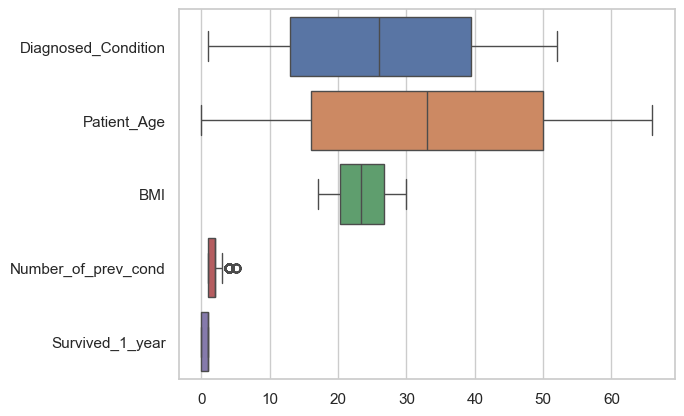

In [28]:
sns.set(style='whitegrid')
ax = sns.boxplot(data = df, orient = 'h')

### 11- Chercher les colonnes qui ont des valeurs abbérantes en affichant le boxplot pour tout le dataset

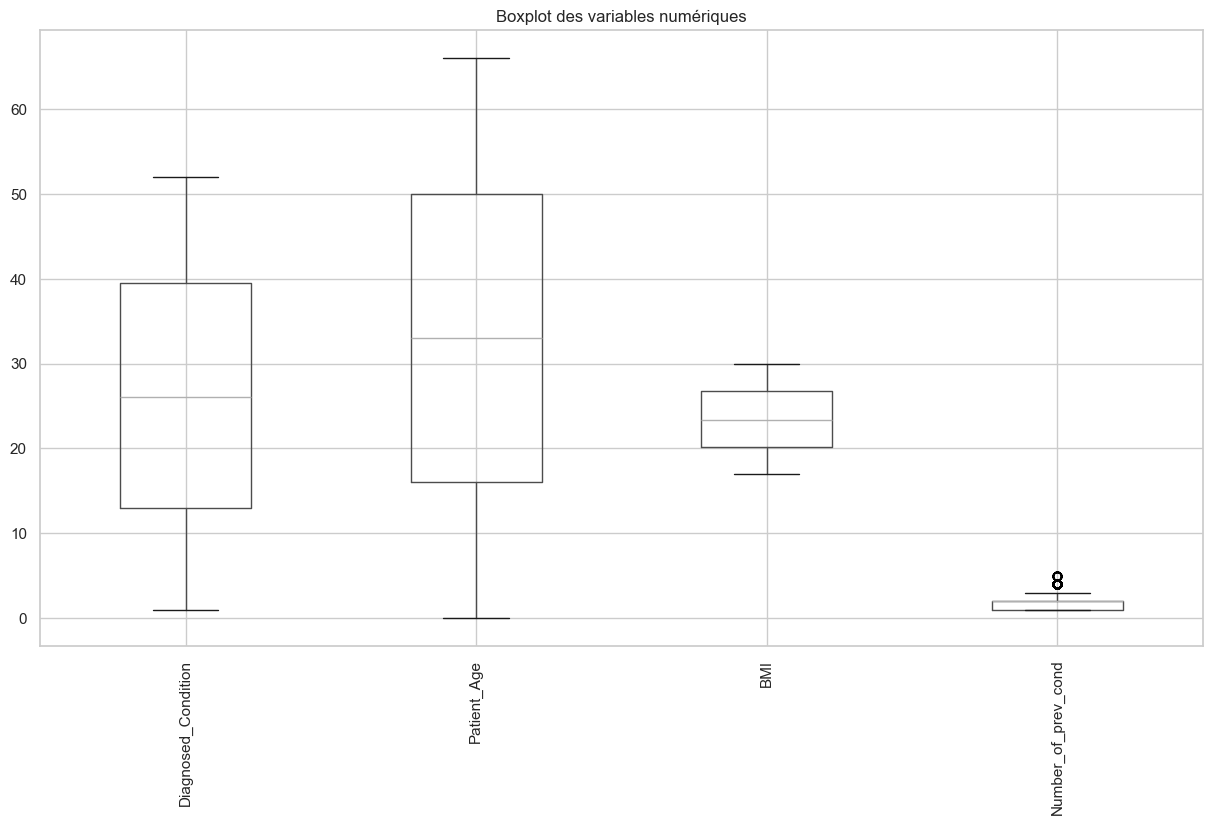

In [29]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15,8))
df[numeric_cols].boxplot(rot=90)
plt.title("Boxplot des variables numériques")
plt.show()

### 12- Nous allons traiter les valeurs abbérantes que la colonne "Patient_Age" en remplaçant ces valeurs par la médiane

In [30]:
df['Patient_Age'].max()

66

#### a-calculer les 4 quartiles (Q1,Q3,IRQ) et Sup, Inf

In [31]:
Q1 = df['Patient_Age'].quantile(0.25)
Q3 = df['Patient_Age'].quantile(0.75)
IQR = Q3 - Q1

limite_basse = Q1 - 1.5 * IQR
limite_haute = Q3 + 1.5 * IQR

# Extraire les outliers pour les voir
outliers = df[(df['Patient_Age'] < limite_basse) | (df['Patient_Age'] > limite_haute)]
print(f"Nombre d'outliers détectés : {len(outliers)}")

Nombre d'outliers détectés : 0


#### b-remplacer les VA par la mediane de la colonne

In [32]:
median_age = df["Patient_Age"].median()
df.loc[
    (df["Patient_Age"] < limite_basse) | 
    (df["Patient_Age"] > limite_haute),
    "Patient_Age"
] = median_age

#### c-vérifier la modification des VA

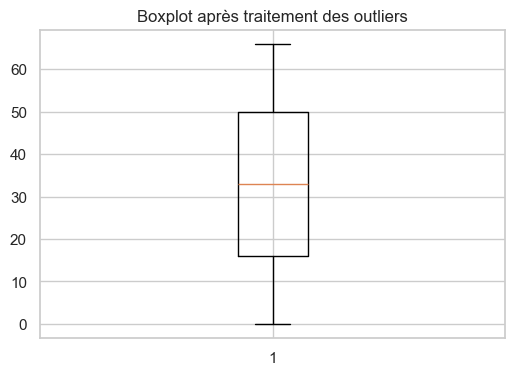

In [33]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Patient_Age"])
plt.title("Boxplot après traitement des outliers")
plt.show()

### 13- supprimer les VA de la colonne 'BMI'

In [34]:
Q1=df['BMI'].quantile(0.25)
Q3=df['BMI'].quantile(0.75)
IQR=Q3-Q1
Inf = df['BMI'].quantile(0.25)-1.5*IQR
Sup = df['BMI'].quantile(0.75)+1.5*IQR

In [35]:
print(Q1)
print(Q3)

20.201489794001333
26.730560447326244


In [36]:
print('Inf=',Inf)
print('Sup=',Sup)

Inf= 10.407883814013966
Sup= 36.52416642731361


In [37]:
(df['BMI']<=Inf).sum()

0

In [38]:
(df['BMI']>=Sup).sum()

0

In [39]:
for i in df['BMI']:
     if i >=Sup or i<=Inf:
            df['BMI']=df['BMI'].replace(i,25)

In [40]:
(df['BMI']<=Inf).sum()

0

In [41]:
Q1=df['Number_of_prev_cond'].quantile(0.25)
Q3=df['Number_of_prev_cond'].quantile(0.75)
IQR=Q3-Q1
Inf = df['Number_of_prev_cond'].quantile(0.25)-1.5*IQR
Sup = df['Number_of_prev_cond'].quantile(0.75)+1.5*IQR

In [42]:
print('Inf=',Inf)
print('Sup=',Sup)

Inf= -0.5
Sup= 3.5


In [43]:
df['Number_of_prev_cond']>=Sup

0        False
1        False
2        False
3        False
4        False
         ...  
23726    False
23727    False
23728    False
23729    False
23730    False
Name: Number_of_prev_cond, Length: 23723, dtype: bool

In [44]:
(df['Number_of_prev_cond']<=Inf).sum()

0

In [45]:
(df['Number_of_prev_cond']>=Sup).sum()

444

In [46]:
df.loc[df['Number_of_prev_cond']>=Sup]

,Diagnosed_Condition,Patient_Age,BMI,Smoker,Residence,mental_condition,Number_of_prev_cond,Survived_1_year
125,48,44,22.141638,NO,RURAL,Stable,4.0,1
178,12,46,24.306519,YES,RURAL,Stable,4.0,0
269,42,40,26.675310,NO,RURAL,Stable,4.0,1
324,20,46,20.687741,NO,RURAL,Stable,4.0,0
335,46,19,29.269717,YES,RURAL,Stable,4.0,0
...,...,...,...,...,...,...,...,...
23605,43,50,26.110402,NO,RURAL,Stable,4.0,1
23611,39,19,29.269717,YES,RURAL,Stable,4.0,0
23631,31,48,28.770051,YES,RURAL,Stable,4.0,0
23635,3,40,26.675310,NO,RURAL,Stable,4.0,1


In [47]:
for i in df['Number_of_prev_cond']:
     if i >=Sup or i<=Inf:
            df['Number_of_prev_cond']=df['Number_of_prev_cond'].replace(i,(Inf+Sup)/2)

In [48]:
(df['Number_of_prev_cond']>=Sup).sum()

0

In [49]:
df.describe()

,Diagnosed_Condition,Patient_Age,BMI,Number_of_prev_cond,Survived_1_year
count,23723.000000,23723.000000,23723.000000,23723.000000,23723.000000
mean,26.388568,33.168191,23.444996,1.702556,0.633183
std,15.090898,19.446006,3.761773,0.676480,0.481946
min,1.000000,0.000000,17.000336,1.000000,0.000000
25%,13.000000,16.000000,20.201490,1.000000,0.000000
50%,26.000000,33.000000,23.372415,2.000000,1.000000
75%,39.500000,50.000000,26.730560,2.000000,1.000000
max,52.000000,66.000000,29.999579,3.000000,1.000000


### 14- affecter à Y (cible) la dernière colonne (Survived_1_year) et le reste du dataframe au entrées X

In [50]:
Y = df['Survived_1_year']
X = df.drop('Survived_1_year', axis=1)

### 15- afficher un echontillion de X et Y

In [51]:
print(X.head())
print(Y.head())

   Diagnosed_Condition  Patient_Age        BMI Smoker Residence  \
0                   47           60  21.655523     NO     URBAN   
1                    3            2  28.852743     NO     RURAL   
2                    7           20  26.179725     NO     RURAL   
3                   31            8  22.638945     NO     RURAL   
4                   43           53  21.326131     NO     RURAL   

  mental_condition  Number_of_prev_cond  
0           Stable                  2.0  
1           Stable                  3.0  
2           Stable                  2.0  
3           Stable                  2.0  
4           Stable                  1.0  
0    1
1    0
2    1
3    0
4    1
Name: Survived_1_year, dtype: int32


### 16- Transformer X et Y en tableau numpy

In [52]:
X_np = X.to_numpy()
Y_np = Y.to_numpy()

### 17- transformer les colonnes catégoriques "Smoker", "Residence" et "mental_condition" en numérique

In [53]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['Smoker'] = le.fit_transform(X['Smoker'])
X['Residence'] = le.fit_transform(X['Residence'])
X['mental_condition'] = le.fit_transform(X['mental_condition'])

### 18- Vérifier cette transformation

In [54]:
print(X[['Smoker', 'Residence', 'mental_condition']].head(10))
print('\nTypes des colonnes :')
print(X[['Smoker', 'Residence', 'mental_condition']].dtypes)

   Smoker  Residence  mental_condition
0       0          1                 0
1       0          0                 0
2       0          0                 0
3       0          0                 0
4       0          0                 0
5       0          0                 0
6       0          0                 0
7       0          1                 0
8       1          0                 0
9       0          0                 0

Types des colonnes :
Smoker              int32
Residence           int32
mental_condition    int32
dtype: object


### 19- Subdiviser la dataset en deux parties train et test

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

### 20- Mettre à l'échelle par standardisation les variables en entrée X_train et X_test

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('X_train après standardisation (5 premières lignes) :')
print(X_train_sc[:5])
print('\nMoyenne de X_train_sc (doit être ~0) :', X_train_sc.mean(axis=0).round(4))
print('Ecart-type de X_train_sc (doit être ~1) :', X_train_sc.std(axis=0).round(4))

X_train après standardisation (5 premières lignes) :
[[-1.35220483 -0.884364   -1.68356999  1.15749103  1.5268356   0.
   1.92594612]
 [ 0.30552209  0.45501175 -0.18173475 -0.86393758 -0.65494936  0.
  -1.03791869]
 [ 1.63170363 -0.93587845 -0.12119446 -0.86393758  1.5268356   0.
  -0.29695249]
 [-0.49018683 -0.62679174  0.58308205  1.15749103 -0.65494936  0.
   1.92594612]
 [-1.1532776  -1.60556633 -1.41324359 -0.86393758  1.5268356   0.
   0.44401371]]

Moyenne de X_train_sc (doit être ~0) : [-0. -0.  0.  0.  0.  0. -0.]
Ecart-type de X_train_sc (doit être ~1) : [1. 1. 1. 1. 1. 0. 1.]


# Modélisation KNN et évaluation

In [57]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train_sc,y_train)
y_pred_knn = knn.predict(X_test_sc)

In [58]:
y_train

2945     0
18628    0
17774    0
5105     1
19601    0
        ..
21583    0
5393     1
860      0
15802    1
23662    1
Name: Survived_1_year, Length: 18978, dtype: int32

In [59]:
y_pred_knn

array([1, 1, 1, ..., 0, 1, 0])

In [60]:
y_test

10369    1
3569     0
19364    1
18025    0
22262    0
        ..
9286     0
6027     1
20736    1
16290    1
4156     1
Name: Survived_1_year, Length: 4745, dtype: int32

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix,recall_score,precision_score,f1_score
knn_acc=accuracy_score(y_test,y_pred_knn)
knn_prec=precision_score(y_test,y_pred_knn)
knn_rec=recall_score(y_test,y_pred_knn)
knn_f1_score=f1_score(y_test,y_pred_knn)
print('Confusion matrix knn \n', confusion_matrix(y_test,y_pred_knn))
print('Accuracy knn', knn_acc)
print('precision knn', knn_prec)
print('recall knn', knn_rec)
print('f1_score knn', knn_f1_score)

Confusion matrix knn 
 [[1067  764]
 [ 572 2342]]
Accuracy knn 0.718440463645943
precision knn 0.7540244687701223
recall knn 0.8037062457103638
f1_score knn 0.7780730897009966


In [62]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.65      0.58      0.61      1831
           1       0.75      0.80      0.78      2914

    accuracy                           0.72      4745
   macro avg       0.70      0.69      0.70      4745
weighted avg       0.71      0.72      0.72      4745



# Mdélisation Grid Search et évaluation

In [63]:
from sklearn.model_selection import GridSearchCV
parameters = {'n_neighbors' : [1,3,5,7,9,11,13]}
model = KNeighborsClassifier()
clf = GridSearchCV(model, parameters, scoring='recall', cv=5)
grille = clf.fit(X_train_sc,y_train)
print(grille.best_params_)
print(grille.best_score_)

{'n_neighbors': 13}
0.8682582659095971


In [64]:
y_pred_knn_o = grille.predict(X_test_sc)
knn_op_acc=accuracy_score(y_test,y_pred_knn_o)
knn_op_prec=precision_score(y_test,y_pred_knn_o)
knn_op_rec=recall_score(y_test,y_pred_knn_o)
knn_op_rec=recall_score(y_test,y_pred_knn)
knn_op_f1_score=f1_score(y_test,y_pred_knn)
print('Confusion matrix knn \n', confusion_matrix(y_test,y_pred_knn))
print('Accuracy knn', knn_op_acc)
print('precision knn', knn_op_prec)
print('recall knn', knn_op_rec)
print('f1_score knn', knn_op_f1_score)

Confusion matrix knn 
 [[1067  764]
 [ 572 2342]]
Accuracy knn 0.746259220231823
precision knn 0.750733137829912
recall knn 0.8037062457103638
f1_score knn 0.7780730897009966


# Decision Tree

# Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500)
rf.fit(X_train,y_train)
# 500 nombre d'arbre et prend 80ù de X_train (8000)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [73]:
y_pred_rf = rf.predict(X_test)

In [74]:
rf_acc=accuracy_score(y_test,y_pred_rf)
rf_prec=precision_score(y_test,y_pred_rf)
rf_rec=recall_score(y_test,y_pred_rf)
rf_f1_score=f1_score(y_test,y_pred_rf)
print('Confusion matrix rf \n', confusion_matrix(y_test,y_pred_rf))
print('Accuracy rf', rf_acc)
print('Recall rf', rf_rec)
print('Precision rf', rf_prec)
print('f1_score rf', rf_f1_score)

Confusion matrix rf 
 [[1105  726]
 [ 421 2493]]
Accuracy rf 0.7582718651211802
Recall rf 0.8555250514756348
Precision rf 0.7744641192917054
f1_score rf 0.8129789662481657


In [75]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.72      0.60      0.66      1831
           1       0.77      0.86      0.81      2914

    accuracy                           0.76      4745
   macro avg       0.75      0.73      0.74      4745
weighted avg       0.76      0.76      0.75      4745



## Importance des features

In [81]:
X.head()

,Diagnosed_Condition,Patient_Age,BMI,Smoker,Residence,mental_condition,Number_of_prev_cond
0,47,60,21.655523,0,1,0,2.0
1,3,2,28.852743,0,0,0,3.0
2,7,20,26.179725,0,0,0,2.0
3,31,8,22.638945,0,0,0,2.0
4,43,53,21.326131,0,0,0,1.0


In [82]:
features = ['Diagnosed_Condition', 'Patient_Age', 'BMI', 'Smoker', 'Residence', 'mental_condition', 'Number_of_prev_cond']

In [83]:
importances = rf.feature_importances_

In [84]:
importances

array([0.2645028 , 0.22572471, 0.37546995, 0.06763535, 0.02329458,
       0.        , 0.04337262])

In [85]:
sorted_idx = np.argsort(importances)

In [86]:
features_arr = np.asarray(features)

Text(0.5, 1.0, 'Variable importance')

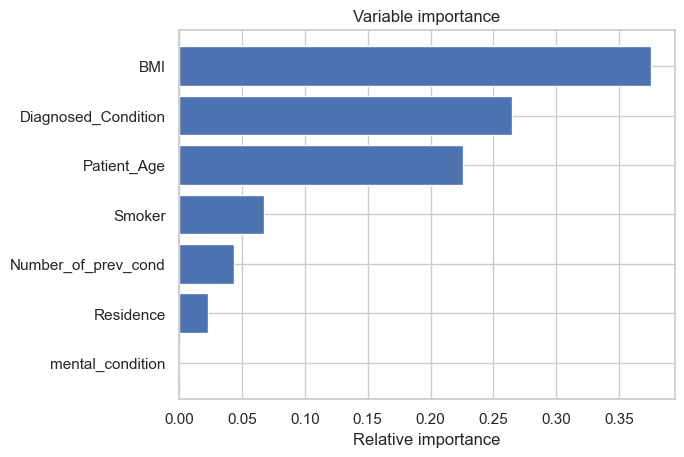

In [87]:
# espace entre les différentes barres
padding=np.arange(X_train_sc.size/len(X_train_sc))
plt.barh(padding,importances[sorted_idx],align='center')
plt.yticks(padding,features_arr[sorted_idx])
plt.xlabel('Relative importance')
plt.title('Variable importance')

# SVM linéaire

In [88]:
from sklearn.svm import SVC
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(X_train_sc,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [89]:
y_pred_svm_l = linear_SVM.predict(X_test_sc)

In [90]:
svm_l_acc=accuracy_score(y_test,y_pred_svm_l)
svm_l_prec=precision_score(y_test,y_pred_svm_l)
svm_l_rec=recall_score(y_test,y_pred_svm_l)
svm_l_f1_score=recall_score(y_test,y_pred_svm_l)
print(confusion_matrix(y_test,y_pred_svm_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_l_acc))
print('Precision linear SVM {0:.3f}'.format(svm_l_prec))
print('Recall linear SVM {0:.3f}'.format(svm_l_rec))
print('f1_score linear SVM {0:.3f}'.format(svm_l_f1_score))

[[   0 1831]
 [   0 2914]]
Accuracy linear SVM 0.614
Precision linear SVM 0.614
Recall linear SVM 1.000
f1_score linear SVM 1.000


In [97]:
print(classification_report(y_test,y_pred_svm_l))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1831
           1       0.61      1.00      0.76      2914

    accuracy                           0.61      4745
   macro avg       0.31      0.50      0.38      4745
weighted avg       0.38      0.61      0.47      4745



# SVM Kernel

In [91]:
kernel_SVM = SVC(kernel='rbf')
# utilisation des données standardisées
kernel_SVM.fit(X_train_sc,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [92]:
y_pred_SVM_k = kernel_SVM.predict(X_test_sc)
svm_k_acc=accuracy_score(y_test,y_pred_SVM_k)
svm_k_prec=precision_score(y_test,y_pred_SVM_k)
svm_k_rec=recall_score(y_test,y_pred_SVM_k)
svm_k_f1_score=f1_score(y_test,y_pred_SVM_k)
print(confusion_matrix(y_test,y_pred_SVM_k))
print('Accuracy rbf SVM {0:.3f}'.format(svm_k_acc))
print('Precision rbf SVM {0:.3f}'.format(svm_k_prec))
print('Recall rbf SVM {0:.3f}'.format(svm_k_rec))
print('F1_score rbf SVM {0:.3f}'.format(svm_k_f1_score))

[[ 810 1021]
 [ 257 2657]]
Accuracy rbf SVM 0.731
Precision rbf SVM 0.722
Recall rbf SVM 0.912
F1_score rbf SVM 0.806


In [98]:
print(classification_report(y_test,y_pred_SVM_k))

              precision    recall  f1-score   support

           0       0.76      0.44      0.56      1831
           1       0.72      0.91      0.81      2914

    accuracy                           0.73      4745
   macro avg       0.74      0.68      0.68      4745
weighted avg       0.74      0.73      0.71      4745



# Logistic Regression

In [93]:
# un modèle est dit probabiliste s'il donne un resultat 0 ou 1
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(X_train_sc,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [94]:
y_predictLR = LR.predict(X_test_sc)

In [95]:
print(confusion_matrix(y_test,y_predictLR))
LR_acc=accuracy_score(y_test,y_predictLR)
LR_prec=precision_score(y_test,y_predictLR)
LR_rec=recall_score(y_test,y_predictLR) #average='macro'
LR_f1_score=f1_score(y_test,y_predictLR)
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))
print('f1_score Logistic Regression {0:.3f}'.format(LR_f1_score))

[[ 692 1139]
 [ 340 2574]]
Accuracy Logistic Regression 0.688
Precision Logistic Regression 0.693
Recall Logistic Regression 0.883
f1_score Logistic Regression 0.777


In [96]:
print(classification_report(y_test,y_predictLR))

              precision    recall  f1-score   support

           0       0.67      0.38      0.48      1831
           1       0.69      0.88      0.78      2914

    accuracy                           0.69      4745
   macro avg       0.68      0.63      0.63      4745
weighted avg       0.68      0.69      0.66      4745



# Sommary